# 02 — LLM-Based Requirements Extraction

This notebook prototypes and evaluates the LLM-based extraction pipeline used to convert unstructured job descriptions into structured requirement data.

The analysis focuses on:
- extracting relevant requirement sections from noisy HTML job postings
- designing and refining prompts for structured extraction
- testing local LLMs for requirement parsing
- validating extracted tools, concepts, education requirements, and experience ranges

The goal is to transform raw job descriptions into structured, analytics-ready requirement records.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('../src')))

In [71]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import json

from bs4 import BeautifulSoup

from config import config 

In [3]:
from IPython.display import display, HTML
from processing.section_extractor import extract_requirements
from ollama import Client

## Load Data

In [4]:
with duckdb.connect(config.db_path) as con:
    df = con.execute("""
        SELECT 
            p.source_job_id as job_id,
            p.raw_json->>'title' AS title,
            d.html_description,
        FROM jobs_raw p
        JOIN descriptions_raw d
        ON p.source_job_id = d.source_job_id
    """).df()

In [5]:
df.head()

,job_id,title,html_description
0,5682401255,Data Scientist,"<p><b>What You’ll Do:</b></p><p style=""""></p><..."
1,5680603425,"Data Scientist, Private Brand Analytics",This role is on the Core Tech Private Brands A...
2,5681563887,AI/ML Engineer,We are looking for a Machine Learning Engineer...
3,5679503416,"Student Researcher, BS/MS, Winter/Summer 2026",<i>info_outline</i>X<p>Applications will be re...
4,5678375940,Senior AI/ML Research Engineer,Push the boundaries of AI innovation while con...


## Requirement Section Extraction
Reduce each description to the most relevant requirement-oriented text before applying structured extraction.

### Isolating the requirement section
This step is meant to reduce noise, lower token usage, and improve extraction consistency.
Before text reduction comparison

In [6]:
sample_desc = df["html_description"].sample(n=1, random_state=40).values[0]
display(HTML(sample_desc))

In [7]:
requirements_text = extract_requirements(sample_desc)
print(requirements_text)

2 to 4 years of experience in technical support, DevOps, SRE, or similar roles
Strong Linux command-line skills
Comfortable with SSH, Docker, and basic shell scripting
Familiarity with AWS services
Experience querying relational databases
Ability to read TypeScript or Node.js code to trace logic and debug issues
Strong written communication skills for customer tickets and internal GitHub documentation
Experience with network tunneling or proxy setups
Familiarity with LLM API providers (Anthropic, OpenAI), including billing, rate limits, and tiers
Experience with container orchestration beyond basic Docker


#### Text reduction check

In [8]:
def measure_text_reduction(html):
    soup = BeautifulSoup(html, "html.parser")
    desc = soup.get_text("\n", strip=True)
    req_section = extract_requirements(html)
    return 100 * (len(desc) - len(req_section)) / len(desc)

In [9]:
df["text_reduction_pct"] = df["html_description"].apply(measure_text_reduction)

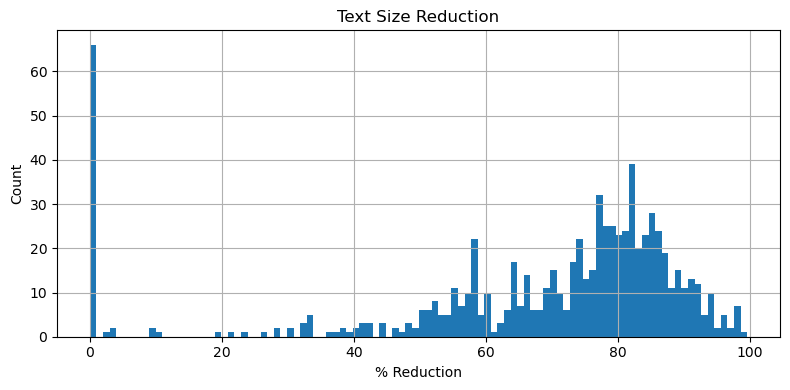

In [10]:
df["text_reduction_pct"].hist(bins=100, figsize=(8,4))
plt.title("Text Size Reduction")
plt.xlabel("% Reduction")
plt.ylabel("Count")
plt.tight_layout()

### 2. Technical Skills Extraction

In [27]:
SYSTEM_PROMPT = """
Extract job requirements from the text.

Return valid JSON only with exactly these keys:
- technical_tools
- technical_concepts
- min_years
- max_years
- certifications

Rules:
- technical_tools: named software, programming languages, frameworks, libraries, platforms, and cloud tools.
- technical_concepts: non-tool technical domains, methods, and practices such as machine learning, data modeling, ETL, data governance, MLOps, statistics, experimentation, NLP, computer vision, API design, or distributed systems. Do not include software tools, programming languages, cloud platforms, or generic job responsibilities.
- min_years and max_years must be integers or null.
- certifications must be a list of explicitly stated certifications.
- Use empty lists for missing list fields.
- Use null for missing year fields.
- Never return ["None"], ["N/A"], ["not specified"], ["not mentioned"], or similar placeholder strings.
- If no education or certification is stated, return [].
- Do not invent requirements not present in the text.
- Do not include explanations.

Before answering, verify that every extracted item appears in or is directly supported by the text.
""".strip()

In [28]:
client = Client(host="http://localhost:11434")

In [29]:
def get_completion(description: str, model: str = "gemma3:4b") -> str:
    response = client.chat(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"{description}"},
        ],
        options={"temperature": 0},
    )
    return response["message"]["content"]

In [30]:
%%time
result = get_completion(requirements_text)
print(result)

INFO:httpx:HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


```json
{
  "technical_tools": [
    "SSH",
    "Docker",
    "Node.js",
    "TypeScript",
    "Anthropic",
    "OpenAI"
  ],
  "technical_concepts": [
    "Linux command-line",
    "Shell scripting",
    "Relational databases",
    "Container orchestration",
    "API design"
  ],
  "min_years": 2,
  "max_years": 4,
  "certifications": []
}
```
CPU times: total: 0 ns
Wall time: 8.17 s
